# **🍃 Renewable Energy Consumption and Generation Analytics for College Campuses**

---


# **Problem Statement**
Government campuses across India consume large amounts of electricity every day to support classrooms, laboratories, hostels, libraries, and other facilities. To reduce electricity costs and carbon emissions, many campuses are adopting renewable energy sources such as solar panels and wind turbines along with battery storage systems.

However, managing multiple energy sources efficiently is challenging. Energy generation from solar and wind depends on weather conditions, while energy demand varies throughout the day. Without proper analysis, it becomes difficult to understand energy consumption patterns, renewable energy contribution, battery utilization, grid dependency, and sustainability performance.

This project focuses on analysing renewable energy and energy consumption data from 150 campuses across India to understand energy usage patterns, evaluate renewable energy performance, support forecasting, and identify opportunities for more effective energy management.

---

# **DIMENSIONAL TABLES**


---

# CAMPUS DATASET


---



In [1]:
import pandas as pd

In [2]:
campus_df = pd.read_excel("/content/Dim_Campus_150.xlsx")

In [3]:
print(campus_df.shape)

(150, 10)


In [4]:
campus_df.head()

,campus_id,campus_name,state,region,campus_type,ownership_type,student_population,staff_population,latitude,longitude
0,1,Campus_001,Andhra Pradesh,South,Research Institute,Autonomous,4916,1198,18.590004,77.769776
1,2,Campus_002,Rajasthan,West,Government Campus,Central Government,13182,1339,29.326939,73.725118
2,3,Campus_003,Bihar,East,Government Campus,State Government,10226,691,26.333976,83.575830
3,4,Campus_004,Andhra Pradesh,South,Polytechnic,Autonomous,1594,351,15.042515,79.979131
4,5,Campus_005,Uttar Pradesh,North,Research Institute,Autonomous,3883,306,26.212565,81.180879


In [5]:
campus_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   campus_id           150 non-null    int64  
 1   campus_name         150 non-null    object 
 2   state               150 non-null    object 
 3   region              150 non-null    object 
 4   campus_type         150 non-null    object 
 5   ownership_type      150 non-null    object 
 6   student_population  150 non-null    int64  
 7   staff_population    150 non-null    int64  
 8   latitude            150 non-null    float64
 9   longitude           150 non-null    float64
dtypes: float64(2), int64(3), object(5)
memory usage: 11.8+ KB


In [6]:
campus_df.describe(include='all')

,campus_id,campus_name,state,region,campus_type,ownership_type,student_population,staff_population,latitude,longitude
count,150.000000,150,150,150,150,150,150.000000,150.000000,150.000000,150.000000
unique,NaN,150,18,5,5,3,NaN,NaN,NaN,NaN
top,NaN,Campus_001,Assam,South,Research Institute,Central Government,NaN,NaN,NaN,NaN
freq,NaN,1,13,51,37,51,NaN,NaN,NaN,NaN
mean,75.500000,NaN,NaN,NaN,NaN,NaN,9346.093333,904.526667,22.099032,79.947614
std,43.445368,NaN,NaN,NaN,NaN,NaN,7346.959933,617.467937,6.479740,5.799909
min,1.000000,NaN,NaN,NaN,NaN,NaN,885.000000,120.000000,8.314442,68.769185
25%,38.250000,NaN,NaN,NaN,NaN,NaN,3781.250000,436.500000,17.155035,76.273343
50%,75.500000,NaN,NaN,NaN,NaN,NaN,6479.000000,725.000000,24.075575,77.988665
75%,112.750000,NaN,NaN,NaN,NaN,NaN,13270.500000,1195.500000,27.455518,82.087994


In [7]:
campus_df.isnull().sum()

,0
campus_id,0
campus_name,0
state,0
region,0
campus_type,0
ownership_type,0
student_population,0
staff_population,0
latitude,0
longitude,0


In [8]:
campus_df['region'].value_counts()

,count
region,
South,51
North,36
East,35
West,17
Central,11


In [9]:
campus_df['campus_type'].value_counts()

,count
campus_type,
Research Institute,37
Government Campus,31
Polytechnic,30
Engineering College,26
University,26


In [10]:
campus_df['ownership_type'].value_counts()

,count
ownership_type,
Central Government,51
State Government,51
Autonomous,48


In [11]:
campus_df.nlargest(3, 'student_population')

,campus_id,campus_name,state,region,campus_type,ownership_type,student_population,staff_population,latitude,longitude
32,33,Campus_033,Telangana,South,University,Central Government,29666,1261,16.954824,79.398549
100,101,Campus_101,Telangana,South,University,State Government,29527,2846,18.806486,80.894391
31,32,Campus_032,Tamil Nadu,South,University,State Government,29156,2670,12.319749,78.325837


In [12]:
campus_df.groupby('region')['student_population'].mean()

,student_population
region,
Central,10759.181818
East,9900.942857
North,9202.083333
South,9162.372549
West,8145.529412


In [13]:
campus_df['total_population'] = (
    campus_df['student_population'] + campus_df['staff_population']
)

In [14]:
campus_df.groupby('campus_type')['total_population'].mean().sort_values(ascending=False)

,total_population
campus_type,
University,23253.038462
Engineering College,13737.153846
Government Campus,9550.000000
Polytechnic,4348.200000
Research Institute,4036.540541


In [15]:
campus_df.groupby('region')['total_population'].sum().sort_values(ascending=False)

,total_population
region,
South,511517
East,376758
North,365418
West,153053
Central,130847


In [16]:
campus_df.duplicated().sum()

np.int64(0)

Student population should never be negative.

In [17]:
campus_df[campus_df['student_population'] < 0]

,campus_id,campus_name,state,region,campus_type,ownership_type,student_population,staff_population,latitude,longitude,total_population


Staff population should never be negative.

In [18]:
campus_df[campus_df['staff_population'] < 0]

,campus_id,campus_name,state,region,campus_type,ownership_type,student_population,staff_population,latitude,longitude,total_population


**Latitude range**

For India : 6 to 37

In [19]:
campus_df[
(campus_df['latitude'] < 6) | (campus_df['latitude'] > 37)
]

,campus_id,campus_name,state,region,campus_type,ownership_type,student_population,staff_population,latitude,longitude,total_population


**Longitude range**

India roughly : 68 to 98

In [20]:
campus_df[
(campus_df['longitude'] < 68) | (campus_df['longitude'] > 98)
]

,campus_id,campus_name,state,region,campus_type,ownership_type,student_population,staff_population,latitude,longitude,total_population


Population sanity

In [21]:
campus_df.nsmallest(5,'student_population')

,campus_id,campus_name,state,region,campus_type,ownership_type,student_population,staff_population,latitude,longitude,total_population
146,147,Campus_147,Maharashtra,West,Research Institute,Central Government,885,179,21.901831,73.491926,1064
64,65,Campus_065,Delhi,North,Research Institute,Autonomous,1140,905,28.731133,76.913866,2045
23,24,Campus_024,Assam,East,Research Institute,Autonomous,1491,1005,24.720547,90.406819,2496
134,135,Campus_135,Kerala,South,Research Institute,Autonomous,1546,494,8.314442,74.716099,2040
130,131,Campus_131,West Bengal,East,Polytechnic,State Government,1547,225,21.806677,88.807755,1772


**Summary :**

| Data Quality Check          | Result | Action Taken       |
| --------------------------- | ------ | ------------------ |
| Missing Values              | 0      | No action required |
| Duplicate Records           | 0      | No action required |
| Data Type Issues            | 0      | No action required |
| Text Standardization Issues | 0      | No action required |
| Invalid Coordinates         | 0      | No action required |
| Negative Population Values  | 0      | No action required |


**Data Profiling**

| Metric              | Value |
| ------------------- | ----- |
| Total Records       | 150   |
| Total Columns       | 10    |
| Numerical Columns   | 5     |
| Categorical Columns | 5     |
| Missing Values      | 0     |
| Duplicate Records   | 0     |
| Unique Campus IDs   | 150   |
| States Represented  | 18    |
| Regions Represented | 5     |


# CAMPUS BUILDINGS DATASET


---



In [22]:
buildings_df = pd.read_excel('/content/Dim_Campus_Buildings.xlsx')

In [23]:
buildings_df.shape

(2122, 6)

In [24]:
buildings_df.head()

,building_id,campus_id,building_name,building_type,floor_area_sqft,construction_year
0,1,1,Academic Block_1,Academic Block,118247,2008
1,2,1,Administration_2,Administration,17162,1995
2,3,1,Library_3,Library,25289,2010
3,4,1,Academic Block_4,Academic Block,30060,2017
4,5,1,Academic Block_5,Academic Block,106486,2003


In [25]:
buildings_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2122 entries, 0 to 2121
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   building_id        2122 non-null   int64 
 1   campus_id          2122 non-null   int64 
 2   building_name      2122 non-null   object
 3   building_type      2122 non-null   object
 4   floor_area_sqft    2122 non-null   int64 
 5   construction_year  2122 non-null   int64 
dtypes: int64(4), object(2)
memory usage: 99.6+ KB


In [26]:
buildings_df.describe(include='all')

,building_id,campus_id,building_name,building_type,floor_area_sqft,construction_year
count,2122.000000,2122.000000,2122,2122,2122.000000,2122.000000
unique,NaN,NaN,2122,8,NaN,NaN
top,NaN,NaN,IT Center_2122,Academic Block,NaN,NaN
freq,NaN,NaN,1,737,NaN,NaN
mean,1061.500000,76.483506,NaN,NaN,41315.049010,2004.580584
std,612.712956,43.002834,NaN,NaN,31331.892896,11.486390
min,1.000000,1.000000,NaN,NaN,3044.000000,1985.000000
25%,531.250000,39.000000,NaN,NaN,15835.000000,1995.000000
50%,1061.500000,77.000000,NaN,NaN,30747.500000,2005.000000
75%,1591.750000,114.000000,NaN,NaN,59525.000000,2015.000000


In [27]:
buildings_df.isnull().sum()

,0
building_id,0
campus_id,0
building_name,0
building_type,0
floor_area_sqft,0
construction_year,0


In [28]:
buildings_df.duplicated().sum()

np.int64(0)

In [29]:
buildings_df['building_type'].value_counts()

,count
building_type,
Academic Block,737
Administration,340
Laboratory,332
Library,254
Hostel,243
IT Center,83
Auditorium,68
Sports Complex,65


Floor area cannot be negative.

In [30]:
buildings_df[buildings_df['floor_area_sqft'] <= 0]

,building_id,campus_id,building_name,building_type,floor_area_sqft,construction_year


Construction year should be reasonable.

In [31]:
buildings_df['construction_year'].describe()

,construction_year
count,2122.000000
mean,2004.580584
std,11.486390
min,1985.000000
25%,1995.000000
50%,2005.000000
75%,2015.000000
max,2024.000000


Very old buildings

In [32]:
buildings_df.nsmallest(3,'construction_year')

,building_id,campus_id,building_name,building_type,floor_area_sqft,construction_year
9,10,1,Academic Block_10,Academic Block,87708,1985
14,15,2,Administration_15,Administration,9029,1985
72,73,6,Library_73,Library,20582,1985


Very large buildings

In [33]:
buildings_df.nlargest(3,'floor_area_sqft')

,building_id,campus_id,building_name,building_type,floor_area_sqft,construction_year
877,878,64,Academic Block_878,Academic Block,119840,2024
1932,1933,137,Academic Block_1933,Academic Block,119423,2004
458,459,34,Academic Block_459,Academic Block,119384,1991


In [34]:
invalid_campus_ids = (
    set(buildings_df['campus_id'])
    - set(campus_df['campus_id'])
)

print(invalid_campus_ids)

set()


In [35]:
buildings_df.groupby('campus_id').size()

,0
campus_id,
1,10
2,10
3,12
4,12
5,18
...,...
146,13
147,16
148,12


In [36]:
pd.crosstab(
    buildings_df['campus_id'],
    buildings_df['building_type']
)

building_type,Academic Block,Administration,Auditorium,Hostel,IT Center,Laboratory,Library,Sports Complex
campus_id,,,,,,,,
1,5,1,0,0,1,2,1,0
2,2,2,0,1,0,4,1,0
3,4,1,2,0,1,2,1,1
4,4,2,1,1,0,2,1,1
5,8,3,0,3,0,3,1,0
...,...,...,...,...,...,...,...,...
146,2,6,0,0,1,3,1,0
147,8,2,0,1,2,1,2,0
148,3,2,1,0,2,2,2,0




---
# ASSET DETAILS DATASET


In [37]:
asset_df = pd.read_excel('/content/Dim_Asset_Master.xlsx')

In [38]:
asset_df.shape

(895, 7)

In [39]:
asset_df.head()

,asset_id,campus_id,asset_type,capacity_kw,installation_date,manufacturer,asset_status
0,1,1,Solar PV,771.00,2016-02-26,Luminous,Active
1,2,1,Solar PV,2341.41,2018-08-18,Luminous,Active
2,3,1,Solar PV,790.39,2024-02-05,Luminous,Under Maintenance
3,4,1,Solar PV,2488.55,2020-07-12,ABB,Active
4,5,1,Wind Turbine,216.96,2019-03-18,Luminous,Active


In [40]:
asset_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 895 entries, 0 to 894
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   asset_id           895 non-null    int64  
 1   campus_id          895 non-null    int64  
 2   asset_type         895 non-null    object 
 3   capacity_kw        895 non-null    float64
 4   installation_date  895 non-null    object 
 5   manufacturer       895 non-null    object 
 6   asset_status       895 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 49.1+ KB


In [41]:
asset_df.describe(include='all')

,asset_id,campus_id,asset_type,capacity_kw,installation_date,manufacturer,asset_status
count,895.000000,895.000000,895,895.000000,895,895,895
unique,NaN,NaN,3,NaN,795,10,2
top,NaN,NaN,Solar PV,NaN,2018-03-14,Schneider Electric,Active
freq,NaN,NaN,443,NaN,3,137,671
mean,448.000000,76.481564,NaN,1515.867486,NaN,NaN,NaN
std,258.508543,43.745597,NaN,1092.084496,NaN,NaN,NaN
min,1.000000,1.000000,NaN,63.730000,NaN,NaN,NaN
25%,224.500000,39.000000,NaN,698.800000,NaN,NaN,NaN
50%,448.000000,76.000000,NaN,1276.240000,NaN,NaN,NaN
75%,671.500000,115.000000,NaN,2107.235000,NaN,NaN,NaN


In [42]:
asset_df.isnull().sum()

,0
asset_id,0
campus_id,0
asset_type,0
capacity_kw,0
installation_date,0
manufacturer,0
asset_status,0


In [43]:
asset_df.duplicated().sum()

np.int64(0)

In [44]:
asset_df['asset_type'].value_counts()

,count
asset_type,
Solar PV,443
Battery Storage,232
Wind Turbine,220


In [45]:
asset_df['asset_status'].value_counts()

,count
asset_status,
Active,671
Under Maintenance,224


Can an asset have zero capacity?

In [46]:
asset_df[asset_df['capacity_kw'] <= 0]

,asset_id,campus_id,asset_type,capacity_kw,installation_date,manufacturer,asset_status


Largest Assets

In [47]:
asset_df.nlargest(3,'capacity_kw')

,asset_id,campus_id,asset_type,capacity_kw,installation_date,manufacturer,asset_status
371,372,63,Battery Storage,4989.57,2020-02-25,Schneider Electric,Under Maintenance
202,203,35,Battery Storage,4976.06,2023-12-15,ABB,Active
880,881,148,Battery Storage,4936.74,2023-01-21,Exide,Active


<Axes: >

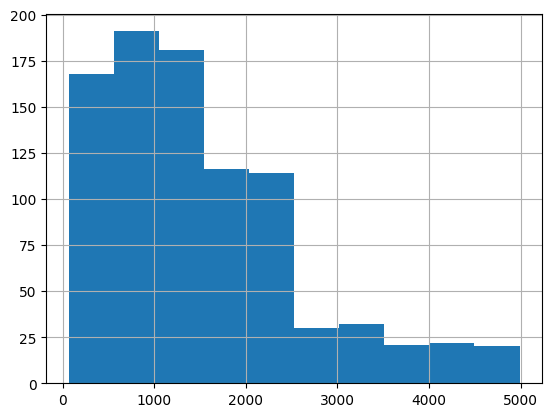

In [48]:
asset_df['capacity_kw'].hist()

Installation Date Validation

In [49]:
asset_df['installation_date'] = pd.to_datetime(
    asset_df['installation_date']
)

In [50]:
asset_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 895 entries, 0 to 894
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   asset_id           895 non-null    int64         
 1   campus_id          895 non-null    int64         
 2   asset_type         895 non-null    object        
 3   capacity_kw        895 non-null    float64       
 4   installation_date  895 non-null    datetime64[ns]
 5   manufacturer       895 non-null    object        
 6   asset_status       895 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(3)
memory usage: 49.1+ KB


Referential Integrity

In [51]:
invalid_assets = (
    set(asset_df['campus_id'])
    - set(campus_df['campus_id'])
)

print(invalid_assets)

set()


Average Capacity By Asset Type

In [52]:
asset_df.groupby(
    'asset_type'
)['capacity_kw'].mean()

,capacity_kw
asset_type,
Battery Storage,2534.393534
Solar PV,1354.989029
Wind Turbine,765.736182


Assets Per Campus

In [53]:
asset_df.groupby('campus_id').size()

,0
campus_id,
1,8
2,7
3,6
4,6
5,4
...,...
146,7
147,5
148,6




---
# LOAD CATEGORY


In [54]:
load_df = pd.read_excel('/content/Dim_Load_Category_Master.xlsx')

In [55]:
load_df.shape

(7, 5)

In [56]:
load_df.head()

,load_category_id,load_category_name,description,priority_level,criticality
0,1,HVAC,Heating Ventilation and Air Conditioning Systems,High,Critical
1,2,Lighting,Indoor and Outdoor Lighting Systems,Medium,Moderate
2,3,Hostel,Student Hostel Power Consumption,High,Critical
3,4,Laboratory,Research and Academic Laboratory Equipment,High,Critical
4,5,Administration,Administrative Offices and Facilities,Medium,Moderate


In [57]:
load_df.isnull().sum()

,0
load_category_id,0
load_category_name,0
description,0
priority_level,0
criticality,0


In [58]:
load_df.duplicated().sum()

np.int64(0)



---

# DATE DATASET

In [59]:
date_df = pd.read_excel('/content/Dim_Date_2021_2025.xlsx')

In [60]:
date_df.shape

(1826, 13)

In [61]:
date_df.head()

,date_key,date,year,quarter,month,month_name,week,day,day_name,is_weekend,holiday_flag,season,academic_term
0,20210101,2021-01-01,2021,1,1,January,53,1,Friday,0,0,Winter,Term 2
1,20210102,2021-01-02,2021,1,1,January,53,2,Saturday,1,0,Winter,Term 2
2,20210103,2021-01-03,2021,1,1,January,53,3,Sunday,1,0,Winter,Term 2
3,20210104,2021-01-04,2021,1,1,January,1,4,Monday,0,0,Winter,Term 2
4,20210105,2021-01-05,2021,1,1,January,1,5,Tuesday,0,0,Winter,Term 2


In [62]:
date_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1826 entries, 0 to 1825
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   date_key       1826 non-null   int64 
 1   date           1826 non-null   object
 2   year           1826 non-null   int64 
 3   quarter        1826 non-null   int64 
 4   month          1826 non-null   int64 
 5   month_name     1826 non-null   object
 6   week           1826 non-null   int64 
 7   day            1826 non-null   int64 
 8   day_name       1826 non-null   object
 9   is_weekend     1826 non-null   int64 
 10  holiday_flag   1826 non-null   int64 
 11  season         1826 non-null   object
 12  academic_term  1826 non-null   object
dtypes: int64(8), object(5)
memory usage: 185.6+ KB


In [63]:
date_df['date'] = pd.to_datetime(
    date_df['date']
)

In [64]:
date_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1826 entries, 0 to 1825
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date_key       1826 non-null   int64         
 1   date           1826 non-null   datetime64[ns]
 2   year           1826 non-null   int64         
 3   quarter        1826 non-null   int64         
 4   month          1826 non-null   int64         
 5   month_name     1826 non-null   object        
 6   week           1826 non-null   int64         
 7   day            1826 non-null   int64         
 8   day_name       1826 non-null   object        
 9   is_weekend     1826 non-null   int64         
 10  holiday_flag   1826 non-null   int64         
 11  season         1826 non-null   object        
 12  academic_term  1826 non-null   object        
dtypes: datetime64[ns](1), int64(8), object(4)
memory usage: 185.6+ KB


In [65]:
date_df.isnull().sum()

,0
date_key,0
date,0
year,0
quarter,0
month,0
month_name,0
week,0
day,0
day_name,0
is_weekend,0


In [66]:
date_df.duplicated().sum()

np.int64(0)

Year should be between 2021 and 2025

In [67]:
date_df[
    (date_df['year'] < 2021) | (date_df['year'] > 2025)
]

,date_key,date,year,quarter,month,month_name,week,day,day_name,is_weekend,holiday_flag,season,academic_term


Month should be between 1 and 12

In [68]:
date_df[
    (date_df['month'] < 1) |
    (date_df['month'] > 12)
]

,date_key,date,year,quarter,month,month_name,week,day,day_name,is_weekend,holiday_flag,season,academic_term


Quarter should be between 1 and 4

In [69]:
date_df[
    (date_df['quarter'] < 1) |
    (date_df['quarter'] > 4)
]

,date_key,date,year,quarter,month,month_name,week,day,day_name,is_weekend,holiday_flag,season,academic_term


Weekend Flag Validation

In [70]:
date_df['is_weekend'].value_counts()

,count
is_weekend,
0,1304
1,522


Day should be between 1 and 31

In [71]:
date_df[
    (date_df['day'] < 1) |
    (date_df['day'] > 31)
]

,date_key,date,year,quarter,month,month_name,week,day,day_name,is_weekend,holiday_flag,season,academic_term




---

# TIME DATASET

In [72]:
time_df = pd.read_excel('/content/Dim_Time_Hourly.xlsx')

In [73]:
time_df.shape

(24, 6)

In [74]:
time_df.head()

,time_key,hour,minute,time_label,peak_period_flag,time_of_use_category
0,1,0,0,00:00,0,Off-Peak
1,2,1,0,01:00,0,Off-Peak
2,3,2,0,02:00,0,Off-Peak
3,4,3,0,03:00,0,Off-Peak
4,5,4,0,04:00,0,Off-Peak


In [75]:
time_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   time_key              24 non-null     int64 
 1   hour                  24 non-null     int64 
 2   minute                24 non-null     int64 
 3   time_label            24 non-null     object
 4   peak_period_flag      24 non-null     int64 
 5   time_of_use_category  24 non-null     object
dtypes: int64(4), object(2)
memory usage: 1.3+ KB


In [76]:
time_df.isnull().sum()

,0
time_key,0
hour,0
minute,0
time_label,0
peak_period_flag,0
time_of_use_category,0


In [77]:
time_df.duplicated().sum()

np.int64(0)

Hour should be between 0 and 23

In [78]:
time_df[
    (time_df['hour'] < 0) |
    (time_df['hour'] > 23)
]

,time_key,hour,minute,time_label,peak_period_flag,time_of_use_category


Dataset should contain exactly 24 records

In [79]:
len(time_df)

24

Unique Hour Validation

In [80]:
time_df['hour'].nunique()

24



---

# EMISSION FACTOR DATASET

In [81]:
emission_df = pd.read_excel('/content/Dim_Emission_Factor_2021_2025.xlsx')

In [82]:
emission_df.shape

(160, 4)

In [83]:
emission_df.head()

,emission_factor_id,state,year,grid_emission_factor_kg_co2_per_kwh
0,1,Andhra Pradesh,2021,0.7
1,2,Arunachal Pradesh,2021,0.7
2,3,Assam,2021,0.7
3,4,Bihar,2021,0.7
4,5,Chhattisgarh,2021,0.7


In [84]:
emission_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160 entries, 0 to 159
Data columns (total 4 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   emission_factor_id                   160 non-null    int64  
 1   state                                160 non-null    object 
 2   year                                 160 non-null    int64  
 3   grid_emission_factor_kg_co2_per_kwh  160 non-null    float64
dtypes: float64(1), int64(2), object(1)
memory usage: 5.1+ KB


In [85]:
emission_df.isnull().sum()

,0
emission_factor_id,0
state,0
year,0
grid_emission_factor_kg_co2_per_kwh,0


In [86]:
emission_df.duplicated().sum()

np.int64(0)

Emission Factor should be positive

In [87]:
emission_df[
    emission_df['grid_emission_factor_kg_co2_per_kwh'] <= 0
]

,emission_factor_id,state,year,grid_emission_factor_kg_co2_per_kwh


Year should be between 2021 and 2025

In [88]:
emission_df[
    (emission_df['year'] < 2021) |
    (emission_df['year'] > 2025)
]

,emission_factor_id,state,year,grid_emission_factor_kg_co2_per_kwh




---

# STATE WISE RENEWABLE ENERGY

In [89]:
state_df = pd.read_excel('/content/Dim_State_Renewable_Benchmark.xlsx')

In [90]:
state_df.shape

(36, 7)

In [91]:
state_df.head()

,state_id,state_name,applications_count,installations_count,households_covered,installation_capacity_mw,subsidy_released_cr
0,1,Andhra Pradesh,1031796,169646,173479,568.01,1047.65
1,2,Arunachal Pradesh,85,1,1,0.00,0.01
2,3,Assam,427218,135524,136210,446.20,987.38
3,4,Bihar,76709,21113,21746,76.05,143.41
4,5,Chhattisgarh,201290,65405,67548,234.43,362.39


In [92]:
state_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   state_id                  36 non-null     int64  
 1   state_name                36 non-null     object 
 2   applications_count        36 non-null     int64  
 3   installations_count       36 non-null     int64  
 4   households_covered        36 non-null     int64  
 5   installation_capacity_mw  36 non-null     float64
 6   subsidy_released_cr       36 non-null     float64
dtypes: float64(2), int64(4), object(1)
memory usage: 2.1+ KB


In [93]:
state_df.isnull().sum()

,0
state_id,0
state_name,0
applications_count,0
installations_count,0
households_covered,0
installation_capacity_mw,0
subsidy_released_cr,0


In [94]:
state_df.duplicated().sum()

np.int64(0)

Applications Count should not be negative

In [95]:
state_df[
    state_df['applications_count'] < 0
]

,state_id,state_name,applications_count,installations_count,households_covered,installation_capacity_mw,subsidy_released_cr


Installation Capacity should not be negative

In [96]:
state_df[
    state_df['installation_capacity_mw'] < 0
]

,state_id,state_name,applications_count,installations_count,households_covered,installation_capacity_mw,subsidy_released_cr


Subsidy Released should not be negative

In [97]:
state_df[
    state_df['subsidy_released_cr'] < 0
]

,state_id,state_name,applications_count,installations_count,households_covered,installation_capacity_mw,subsidy_released_cr




---

# Downloading Dim cleaned datasets

In [98]:
campus_df.to_excel("Dim_Campus_Master_Cleaned.xlsx", index=False)

buildings_df.to_excel("Dim_Building_Master_Cleaned.xlsx", index=False)

asset_df.to_excel("Dim_Asset_Master_Cleaned.xlsx", index=False)

date_df.to_excel("Dim_Date_Cleaned.xlsx", index=False)

time_df.to_excel("Dim_Time_Cleaned.xlsx", index=False)

load_df.to_excel("Dim_Load_Category_Cleaned.xlsx", index=False)

emission_df.to_excel("Dim_Emission_Factor_Cleaned.xlsx", index=False)

state_df.to_excel("Dim_State_Renewable_Benchmark_Cleaned.xlsx", index=False)


# FACT TABLES


---



# Energy Consumption


---



**Phase 1: Data Profiling**

In [99]:
import pandas as pd

In [100]:
pd.set_option('display.float_format', '{:,.0f}'.format)

In [101]:
energy_1_df = pd.read_excel('/content/Fact_Energy_Consumption_2021.xlsx')

In [102]:
energy_1_df.shape

(383250, 10)

In [103]:
energy_1_df.head()

,consumption_record_id,campus_id,date,load_category_id,energy_consumed_kwh,peak_demand_kw,occupancy_pct,energy_cost_inr,is_weekend,data_quality_flag
0,1,1,2021-01-01,1,987,105,92,"6,899",0,Valid
1,2,1,2021-01-01,2,678,73,85,"4,739",0,Valid
2,3,1,2021-01-01,3,374,39,76,"2,611",0,Valid
3,4,1,2021-01-01,4,474,50,80,"3,311",0,Valid
4,5,1,2021-01-01,5,286,30,83,"2,001",0,Valid


In [104]:
energy_1_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383250 entries, 0 to 383249
Data columns (total 10 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   consumption_record_id  383250 non-null  int64         
 1   campus_id              383250 non-null  int64         
 2   date                   383250 non-null  datetime64[ns]
 3   load_category_id       383250 non-null  int64         
 4   energy_consumed_kwh    383250 non-null  float64       
 5   peak_demand_kw         383250 non-null  float64       
 6   occupancy_pct          383250 non-null  float64       
 7   energy_cost_inr        383250 non-null  float64       
 8   is_weekend             383250 non-null  int64         
 9   data_quality_flag      383250 non-null  object        
dtypes: datetime64[ns](1), float64(4), int64(4), object(1)
memory usage: 29.2+ MB


In [105]:
energy_1_df.describe()

,consumption_record_id,campus_id,date,load_category_id,energy_consumed_kwh,peak_demand_kw,occupancy_pct,energy_cost_inr,is_weekend
count,"383,250","383,250",383250,"383,250","383,250","383,250","383,250","383,250","383,250"
mean,"219,000",76,2021-07-02 00:00:00.000000512,4,697,79,76,"5,081",0
min,1,1,2021-01-01 00:00:00,1,7,1,18,52,0
25%,"109,500",38,2021-04-02 00:00:00,2,200,23,69,"1,490",0
50%,"219,000",76,2021-07-02 00:00:00,4,428,49,85,"3,129",0
75%,"328,500",113,2021-10-01 00:00:00,6,878,99,91,"6,344",1
max,"437,999",150,2021-12-31 00:00:00,7,"5,335",593,100,"39,506",1
std,"126,440",43,NaN,2,776,87,22,"5,633",0


In [106]:
energy_1_df.isnull().sum()

,0
consumption_record_id,0
campus_id,0
date,0
load_category_id,0
energy_consumed_kwh,0
peak_demand_kw,0
occupancy_pct,0
energy_cost_inr,0
is_weekend,0
data_quality_flag,0


In [107]:
(energy_1_df.isnull().sum()/len(energy_1_df))*100

,0
consumption_record_id,0
campus_id,0
date,0
load_category_id,0
energy_consumed_kwh,0
peak_demand_kw,0
occupancy_pct,0
energy_cost_inr,0
is_weekend,0
data_quality_flag,0


In [108]:
energy_1_df.duplicated().sum()

np.int64(0)

In [109]:
energy_1_df['data_quality_flag'].value_counts(dropna=False)

,count
data_quality_flag,
Valid,380310
Suspect,2940


**Phase 2: Business Rule Validation**

Energy Consumption

In [110]:
energy_1_df[energy_1_df['energy_consumed_kwh'] < 0]

,consumption_record_id,campus_id,date,load_category_id,energy_consumed_kwh,peak_demand_kw,occupancy_pct,energy_cost_inr,is_weekend,data_quality_flag


Peak Demand

In [111]:
energy_1_df[energy_1_df['peak_demand_kw'] < 0]

,consumption_record_id,campus_id,date,load_category_id,energy_consumed_kwh,peak_demand_kw,occupancy_pct,energy_cost_inr,is_weekend,data_quality_flag


Occupancy

In [112]:
energy_1_df[
(energy_1_df['occupancy_pct'] < 0) | (energy_1_df['occupancy_pct'] > 100)
]

,consumption_record_id,campus_id,date,load_category_id,energy_consumed_kwh,peak_demand_kw,occupancy_pct,energy_cost_inr,is_weekend,data_quality_flag


**Phase 3: Referential Integrity**

In [113]:
set(energy_1_df['campus_id']) - set(campus_df['campus_id'])

set()

In [114]:
set(energy_1_df['load_category_id']) - set(load_df['load_category_id'])

set()

**Phase 4: Missing Value Treatment**

Only 1–2% missing. So we can Impute the missing values.

In [115]:
energy_1_df['occupancy_pct'] = (
    energy_1_df['occupancy_pct'].fillna(energy_1_df['occupancy_pct'].median())
)

In [116]:
energy_1_df['energy_consumed_kwh'] = (
    energy_1_df['energy_consumed_kwh']
    .fillna(energy_1_df['energy_consumed_kwh'].median())
)

In [117]:
energy_1_df['peak_demand_kw'] = (
    energy_1_df['peak_demand_kw'].fillna(energy_1_df['peak_demand_kw'].median())
)

In [118]:
energy_1_df.isnull().sum()

,0
consumption_record_id,0
campus_id,0
date,0
load_category_id,0
energy_consumed_kwh,0
peak_demand_kw,0
occupancy_pct,0
energy_cost_inr,0
is_weekend,0
data_quality_flag,0


**Phase 5 : Outlier Assessment**

Energy Consumption

In [119]:
Q1 = energy_1_df['energy_consumed_kwh'].quantile(0.25)
Q3 = energy_1_df['energy_consumed_kwh'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers_energy = energy_1_df[
(energy_1_df['energy_consumed_kwh'] < lower) | (energy_1_df['energy_consumed_kwh'] > upper)
]

In [120]:
outliers_energy

,consumption_record_id,campus_id,date,load_category_id,energy_consumed_kwh,peak_demand_kw,occupancy_pct,energy_cost_inr,is_weekend,data_quality_flag
2555,2921,2,2021-01-01,1,"2,377",266,97,"16,563",0,Valid
2562,2929,2,2021-01-02,1,"2,010",257,95,"16,586",1,Valid
2576,2945,2,2021-01-04,1,"2,284",241,97,"16,002",0,Valid
2583,2953,2,2021-01-05,1,"2,256",240,99,"15,847",0,Valid
2590,2961,2,2021-01-06,1,"2,364",264,99,"16,603",0,Valid
...,...,...,...,...,...,...,...,...,...,...
370455,423378,145,2021-12-29,2,"2,053",226,85,"14,304",0,Valid
370461,423385,145,2021-12-30,1,"3,057",323,90,"21,384",0,Valid
370462,423386,145,2021-12-30,2,"2,033",227,85,"14,218",0,Valid
370468,423393,145,2021-12-31,1,"2,950",327,90,"20,640",0,Valid


In [121]:
len(outliers_energy)

31030

Peak Demand

In [122]:
Q1 = energy_1_df['peak_demand_kw'].quantile(0.25)
Q3 = energy_1_df['peak_demand_kw'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers_demand = energy_1_df[
(energy_1_df['peak_demand_kw'] < lower) | (energy_1_df['peak_demand_kw'] > upper)
]

In [123]:
outliers_demand

,consumption_record_id,campus_id,date,load_category_id,energy_consumed_kwh,peak_demand_kw,occupancy_pct,energy_cost_inr,is_weekend,data_quality_flag
2555,2921,2,2021-01-01,1,"2,377",266,97,"16,563",0,Valid
2562,2929,2,2021-01-02,1,"2,010",257,95,"16,586",1,Valid
2569,2937,2,2021-01-03,1,"1,863",261,97,"16,854",1,Valid
2576,2945,2,2021-01-04,1,"2,284",241,97,"16,002",0,Valid
2583,2953,2,2021-01-05,1,"2,256",240,99,"15,847",0,Valid
...,...,...,...,...,...,...,...,...,...,...
370455,423378,145,2021-12-29,2,"2,053",226,85,"14,304",0,Valid
370461,423385,145,2021-12-30,1,"3,057",323,90,"21,384",0,Valid
370462,423386,145,2021-12-30,2,"2,033",227,85,"14,218",0,Valid
370468,423393,145,2021-12-31,1,"2,950",327,90,"20,640",0,Valid


In [124]:
outliers_energy.nlargest(5,'energy_consumed_kwh')

,consumption_record_id,campus_id,date,load_category_id,energy_consumed_kwh,peak_demand_kw,occupancy_pct,energy_cost_inr,is_weekend,data_quality_flag
256480,293121,101,2021-05-21,1,"5,335",581,98,"38,635",0,Valid
255913,292473,101,2021-03-01,1,"5,333",567,94,"39,065",0,Valid
256074,292657,101,2021-03-24,1,"5,326",577,92,"39,347",0,Valid
256263,292873,101,2021-04-20,1,"5,326",584,100,"39,300",0,Valid
256333,292953,101,2021-04-30,1,"5,322",590,98,"38,986",0,Valid


The values are valid. Therefore, outliers were retained for analysis.

**Phase 6 : Datatype Cleaning and Summary**

Date Column

In [125]:
energy_1_df['date'] = pd.to_datetime(energy_1_df['date'])

In [126]:
energy_1_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383250 entries, 0 to 383249
Data columns (total 10 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   consumption_record_id  383250 non-null  int64         
 1   campus_id              383250 non-null  int64         
 2   date                   383250 non-null  datetime64[ns]
 3   load_category_id       383250 non-null  int64         
 4   energy_consumed_kwh    383250 non-null  float64       
 5   peak_demand_kw         383250 non-null  float64       
 6   occupancy_pct          383250 non-null  float64       
 7   energy_cost_inr        383250 non-null  float64       
 8   is_weekend             383250 non-null  int64         
 9   data_quality_flag      383250 non-null  object        
dtypes: datetime64[ns](1), float64(4), int64(4), object(1)
memory usage: 29.2+ MB


**Summary**

| Cleaning Activity        | Result                          | Action Taken              |
| ------------------------ | ------------------------------- | ------------------------- |
| Missing Values           | Found in 3 columns              | Median imputation applied |
| Duplicate Records        | 0                               | No action required        |
| Date Datatype            | Object datatype                 | Converted to datetime     |
| Business Rule Validation | Passed                          | No action required        |
| Outlier Assessment       | ~18,000 outliers detected       | Retained after validation |
| Referential Integrity    | Passed                          | No action required        |
| Data Quality Flag        | VALID, MISSING, ANOMALY present | Retained                  |


**Phase 7 : EDA**

Energy Consumption Distribution


In [127]:
print(round(energy_1_df['energy_consumed_kwh'].mean(), 2))

697.11


In [128]:
print(round(energy_1_df['energy_consumed_kwh'].median(), 2))

428.21


Mean > Median -> Right Skewed?

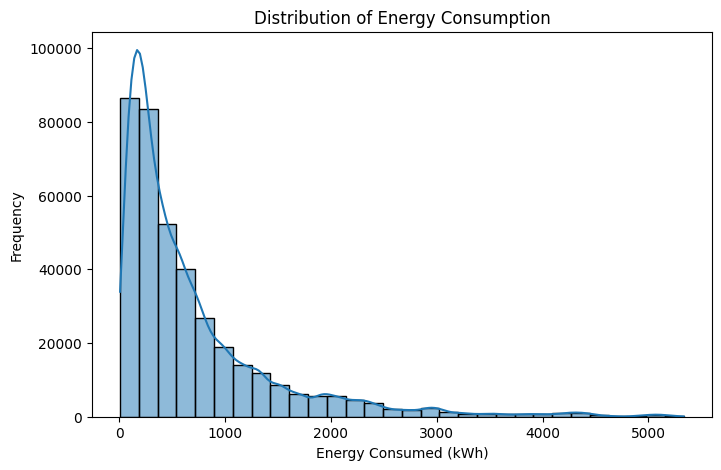

In [129]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(
    energy_1_df['energy_consumed_kwh'],
    bins=30,
    kde=True
)

plt.title('Distribution of Energy Consumption')
plt.xlabel('Energy Consumed (kWh)')
plt.ylabel('Frequency')

plt.show()

In [130]:
energy_1_df['energy_consumed_kwh'].skew()

np.float64(2.3837768030217372)

Skewness greater than 1 means right Skewed

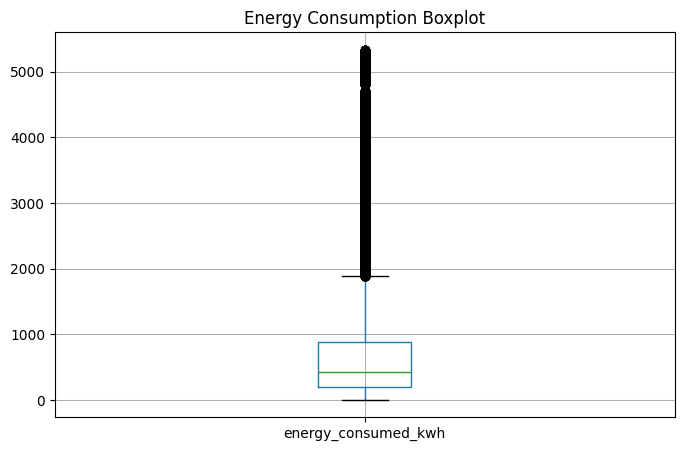

In [131]:
plt.figure(figsize=(8,5))

energy_1_df.boxplot(column='energy_consumed_kwh')

plt.title('Energy Consumption Boxplot')

plt.show()

Outliers Exists. But valid. It supports the IQR findings.

**Questions we want answered:**

**Is the data normally distributed?**
No it is Right Skewed

**Are most observations low consumption?**
Yes

**Top Energy Consuming Campuses**

In [132]:
campus_energy = (
    energy_1_df.groupby('campus_id')['energy_consumed_kwh'].sum()
      .sort_values(ascending=False).reset_index(name='total_energy_kwh')
)

campus_energy.head(10)

,campus_id,total_energy_kwh
0,101,"5,661,371"
1,32,"5,523,044"
2,133,"5,449,220"
3,33,"5,400,958"
4,137,"4,954,080"
5,110,"4,816,350"
6,23,"4,711,307"
7,49,"4,701,491"
8,143,"4,681,960"
9,105,"4,666,689"


No single campus dominates overall energy usage, it is spread across multiple campuses rather than concentrated in one location.

In [133]:
campus_energy.describe().map('{:,.0f}'.format)

,campus_id,total_energy_kwh
count,150,150
mean,76,"1,781,129"
std,43,"1,349,209"
min,1,"184,807"
25%,38,"793,647"
50%,76,"1,225,373"
75%,113,"2,509,334"
max,150,"5,661,371"


Energy Consumption by Load Category

In [134]:
pd.set_option('display.float_format', '{:,.0f}'.format)

In [135]:
energy_by_category = (
    energy_1_df
    .groupby('load_category_id', as_index=False)['energy_consumed_kwh']
    .sum()
    .merge(
        load_df[['load_category_id', 'load_category_name']],
        on='load_category_id',
        how='left'
    )
    [['load_category_id', 'load_category_name', 'energy_consumed_kwh']]
    .sort_values('energy_consumed_kwh', ascending=False)
)

energy_by_category

,load_category_id,load_category_name,energy_consumed_kwh
0,1,HVAC,"85,307,121"
1,2,Lighting,"57,837,744"
3,4,Laboratory,"35,728,322"
2,3,Hostel,"27,312,238"
6,7,Water Systems,"25,589,973"
4,5,Administration,"20,369,902"
5,6,IT Infrastructure,"15,023,989"


In [136]:
energy_by_category['load_category_name'] = (
    energy_by_category['load_category_name']
    .fillna('Unknown')
)

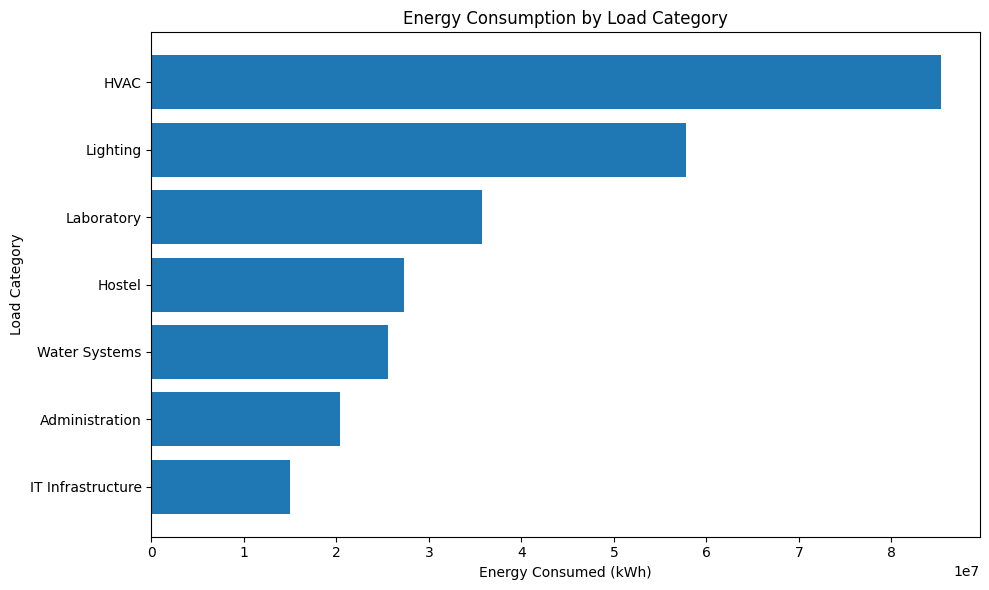

In [137]:
plt.figure(figsize=(10, 6))

plt.barh(
    energy_by_category['load_category_name'],
    energy_by_category['energy_consumed_kwh']
)

plt.title('Energy Consumption by Load Category')
plt.xlabel('Energy Consumed (kWh)')
plt.ylabel('Load Category')

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

Weekend vs Weekday Consumption

In [138]:
(
    energy_1_df.groupby('is_weekend')['energy_consumed_kwh']
    .sum()
    .sort_values(ascending=False)
)

,energy_consumed_kwh
is_weekend,
0,"214,785,491"
1,"52,383,799"


In [139]:
weekend_analysis = energy_1_df.groupby('is_weekend')['energy_consumed_kwh'].sum()

percentage = (weekend_analysis / weekend_analysis.sum() * 100).round(2)

print("Energy Consumed on ")

for is_weekend, pct in percentage.items():
    day_type = "Weekend" if is_weekend else "Weekday"
    print(f"{day_type}: {pct}%")

Energy Consumed on 
Weekday: 80.39%
Weekend: 19.61%


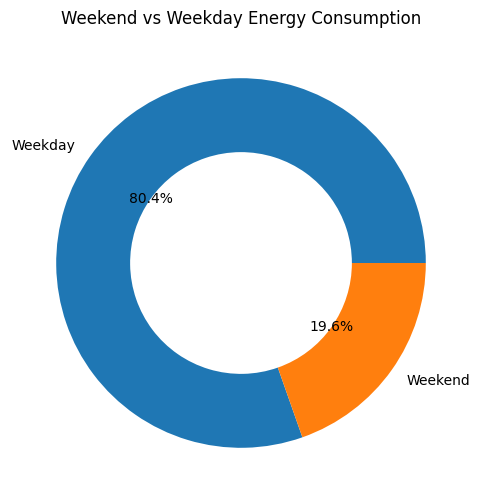

In [140]:
plt.figure(figsize=(6, 6))

plt.pie(
    percentage,
    labels=['Weekday', 'Weekend'],
    autopct='%1.1f%%',
    wedgeprops=dict(width=0.4)
)

plt.title('Weekend vs Weekday Energy Consumption')

plt.show()

Energy Cost vs Energy Consumption

In [141]:
energy_1_df[['energy_consumed_kwh','energy_cost_inr']].corr()

,energy_consumed_kwh,energy_cost_inr
energy_consumed_kwh,1,1
energy_cost_inr,1,1


In [142]:
(
    energy_1_df
    .groupby('load_category_id', as_index=False)
    [['energy_consumed_kwh', 'energy_cost_inr']]
    .sum()
)

,load_category_id,energy_consumed_kwh,energy_cost_inr
0,1,"85,307,121","628,603,329"
1,2,"57,837,744","424,119,329"
2,3,"27,312,238","194,731,591"
3,4,"35,728,322","257,755,233"
4,5,"20,369,902","145,188,756"
5,6,"15,023,989","108,239,995"
6,7,"25,589,973","188,587,790"


Peak Demand Analysis

In [143]:
(
    energy_1_df
    .groupby('load_category_id', as_index=False)['peak_demand_kw']
    .mean()
    .merge(
        load_df[['load_category_id', 'load_category_name']],
        on='load_category_id',
        how='left'
    )
    .sort_values('peak_demand_kw', ascending=False)
)

,load_category_id,peak_demand_kw,load_category_name
0,1,178,HVAC
1,2,120,Lighting
3,4,73,Laboratory
2,3,55,Hostel
6,7,53,Water Systems
4,5,41,Administration
5,6,31,IT Infrastructure


Correlation Analysis

In [144]:
corr_matrix = energy_1_df[
    [
        'energy_consumed_kwh',
        'peak_demand_kw',
        'occupancy_pct',
    ]
].corr()

print(corr_matrix)

                     energy_consumed_kwh  peak_demand_kw  occupancy_pct
energy_consumed_kwh                    1               1              0
peak_demand_kw                         1               1              0
occupancy_pct                          0               0              1


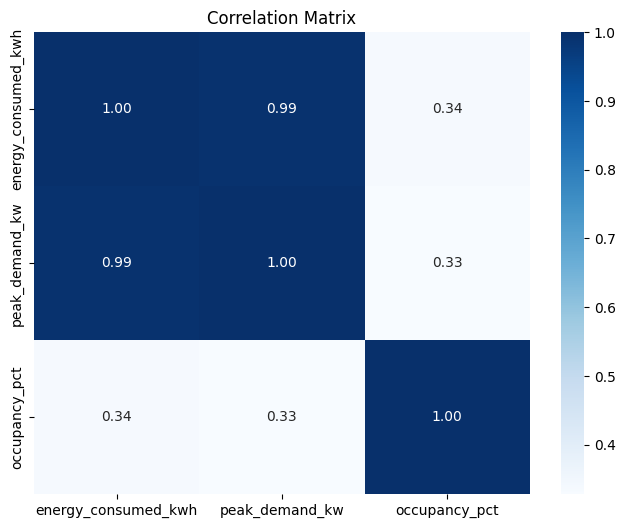

In [145]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='Blues',
    fmt='.2f'
)

plt.title('Correlation Matrix')

plt.show()

In [146]:
import pandas as pd

def clean_energy_data(df):
    df = df.copy()

    # Remove duplicate rows
    df = df.drop_duplicates()

    # Convert date column
    df['date'] = pd.to_datetime(df['date'], errors='coerce')

    # Fill missing numerical values using median
    numeric_cols = [
        'energy_consumed_kwh',
        'peak_demand_kw',
        'occupancy_pct',
        'energy_cost_inr'
    ]

    for col in numeric_cols:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].median())

    # Fill missing categorical values using mode
    categorical_cols = [
        'data_quality_flag'
    ]

    for col in categorical_cols:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].mode()[0])

    # Fill missing datetime values using forward fill
    if 'date' in df.columns:
        df['date'] = df['date'].fillna(method='ffill')

    # Standardize text columns
    text_cols = [
        'data_quality_flag'
    ]

    for col in text_cols:
        if col in df.columns:
            df[col] = (
                df[col]
                .astype(str)
                .str.strip()
                .str.upper()
            )

    return df

In [147]:
energy_2_df = pd.read_excel("/content/Fact_Energy_Consumption_2022.xlsx")
energy_3_df = pd.read_excel("/content/Fact_Energy_Consumption_2023.xlsx")
energy_4_df = pd.read_excel("/content/Fact_Energy_Consumption_2024.xlsx")
energy_5_df = pd.read_excel("/content/Fact_Energy_Consumption_2025.xlsx")

energy_1_df = clean_energy_data(energy_1_df)
energy_2_df = clean_energy_data(energy_2_df)
energy_3_df = clean_energy_data(energy_3_df)
energy_4_df = clean_energy_data(energy_4_df)
energy_5_df = clean_energy_data(energy_5_df)

/tmp/ipykernel_5721/802529194.py:35: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['date'] = df['date'].fillna(method='ffill')
/tmp/ipykernel_5721/802529194.py:35: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['date'] = df['date'].fillna(method='ffill')
/tmp/ipykernel_5721/802529194.py:35: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['date'] = df['date'].fillna(method='ffill')
/tmp/ipykernel_5721/802529194.py:35: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['date'] = df['date'].fillna(method='ffill')
/tmp/ipykernel_5721/802529194.py:35: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future ver

In [148]:
energy_1_df.to_excel("Fact_Energy_Consumption_2021_Cleaned.xlsx", index=False)
energy_2_df.to_excel("Fact_Energy_Consumption_2022_Cleaned.xlsx", index=False)
energy_3_df.to_excel("Fact_Energy_Consumption_2023_Cleaned.xlsx", index=False)
energy_4_df.to_excel("Fact_Energy_Consumption_2024_Cleaned.xlsx", index=False)
energy_5_df.to_excel("Fact_Energy_Consumption_2025_Cleaned.xlsx", index=False)

# Renewable Generation


---



**Phase 1 Findings**

In [149]:
renew1_df = pd.read_excel('/content/Fact_Renewable_Generation_2021.xlsx')

In [150]:
renew1_df.shape

(54750, 11)

In [151]:
renew1_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54750 entries, 0 to 54749
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   generation_record_id      54750 non-null  int64  
 1   campus_id                 54750 non-null  int64  
 2   date                      54750 non-null  object 
 3   solar_generation_kwh      54750 non-null  float64
 4   wind_generation_kwh       54750 non-null  float64
 5   total_generation_kwh      54750 non-null  float64
 6   renewable_capacity_kw     54750 non-null  int64  
 7   capacity_utilization_pct  54750 non-null  float64
 8   weather_dependency_score  54750 non-null  float64
 9   maintenance_impact_flag   54750 non-null  object 
 10  data_quality_flag         54750 non-null  object 
dtypes: float64(5), int64(3), object(3)
memory usage: 4.6+ MB


In [152]:
renew1_df.head()

,generation_record_id,campus_id,date,solar_generation_kwh,wind_generation_kwh,total_generation_kwh,renewable_capacity_kw,capacity_utilization_pct,weather_dependency_score,maintenance_impact_flag,data_quality_flag
0,1,1,2021-01-01,"1,679",97,"1,784",537,14,75,No,Valid
1,2,1,2021-01-02,"1,604",0,"1,601",537,12,69,No,Valid
2,3,1,2021-01-03,"1,568",10,"1,575",537,12,68,No,Valid
3,4,1,2021-01-04,"1,601",0,"1,596",537,12,64,No,Valid
4,5,1,2021-01-05,"1,955",193,"2,152",537,17,78,No,Valid


In [153]:
renew1_df.isnull().sum()

,0
generation_record_id,0
campus_id,0
date,0
solar_generation_kwh,0
wind_generation_kwh,0
total_generation_kwh,0
renewable_capacity_kw,0
capacity_utilization_pct,0
weather_dependency_score,0
maintenance_impact_flag,0


In [154]:
renew1_df.duplicated().sum()

np.int64(0)

In [155]:
renew1_df.describe()

,generation_record_id,campus_id,solar_generation_kwh,wind_generation_kwh,total_generation_kwh,renewable_capacity_kw,capacity_utilization_pct,weather_dependency_score
count,"54,750","54,750","54,750","54,750","54,750","54,750","54,750","54,750"
mean,"27,376",76,"2,517",341,"2,858",899,13,71
std,"15,805",43,917,270,918,229,2,7
min,1,1,157,0,343,505,2,26
25%,"13,688",38,"1,856",118,"2,133",699,12,69
50%,"27,376",76,"2,491",295,"2,836",900,13,73
75%,"41,063",113,"3,182",516,"3,550","1,097",15,76
max,"54,750",150,"4,979","1,603","5,987","1,296",20,95


**Phase 2: Business Rule Validation**

Generation cannot be negative.

In [156]:
renew1_df[
    renew1_df['solar_generation_kwh'] < 0
]

,generation_record_id,campus_id,date,solar_generation_kwh,wind_generation_kwh,total_generation_kwh,renewable_capacity_kw,capacity_utilization_pct,weather_dependency_score,maintenance_impact_flag,data_quality_flag


In [157]:
renew1_df[
    renew1_df['wind_generation_kwh'] < 0
]

,generation_record_id,campus_id,date,solar_generation_kwh,wind_generation_kwh,total_generation_kwh,renewable_capacity_kw,capacity_utilization_pct,weather_dependency_score,maintenance_impact_flag,data_quality_flag


In [158]:
renew1_df[
    renew1_df['total_generation_kwh'] < 0
]

,generation_record_id,campus_id,date,solar_generation_kwh,wind_generation_kwh,total_generation_kwh,renewable_capacity_kw,capacity_utilization_pct,weather_dependency_score,maintenance_impact_flag,data_quality_flag


Capacity Utilization

In [159]:
renew1_df[
(renew1_df['capacity_utilization_pct'] < 0) | (renew1_df['capacity_utilization_pct'] > 100)
]

,generation_record_id,campus_id,date,solar_generation_kwh,wind_generation_kwh,total_generation_kwh,renewable_capacity_kw,capacity_utilization_pct,weather_dependency_score,maintenance_impact_flag,data_quality_flag


Weather Score

In [160]:
renew1_df[
(renew1_df['weather_dependency_score'] < 0) |
(renew1_df['weather_dependency_score'] > 100)
]

,generation_record_id,campus_id,date,solar_generation_kwh,wind_generation_kwh,total_generation_kwh,renewable_capacity_kw,capacity_utilization_pct,weather_dependency_score,maintenance_impact_flag,data_quality_flag


Maintenance Flag

In [161]:
renew1_df['maintenance_impact_flag'].value_counts()

,count
maintenance_impact_flag,
No,52584
Yes,2166


**Phase 3: Referential Integrity**

In [162]:
set(renew1_df['campus_id']) - set(campus_df['campus_id'])

set()

**Phase 4: Missing Value Treatment**

In [163]:
renew1_df[
    ['solar_generation_kwh',
     'wind_generation_kwh',
     'total_generation_kwh']
].head()

,solar_generation_kwh,wind_generation_kwh,total_generation_kwh
0,"1,679",97,"1,784"
1,"1,604",0,"1,601"
2,"1,568",10,"1,575"
3,"1,601",0,"1,596"
4,"1,955",193,"2,152"


In [164]:
renew1_df['solar_generation_kwh'].fillna(
    renew1_df['solar_generation_kwh'].median(),
    inplace=True
)

renew1_df['wind_generation_kwh'].fillna(
    renew1_df['wind_generation_kwh'].median(),
    inplace=True
)

renew1_df['total_generation_kwh'] = (
    renew1_df['solar_generation_kwh']
    +
    renew1_df['wind_generation_kwh']
)

/tmp/ipykernel_5721/3676886235.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  renew1_df['solar_generation_kwh'].fillna(
/tmp/ipykernel_5721/3676886235.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using '

**EDA**

In [165]:
renew1_df[
['solar_generation_kwh',
 'wind_generation_kwh']
].sum()

,0
solar_generation_kwh,"137,805,521"
wind_generation_kwh,"18,666,928"


In [166]:
renew1_df.groupby('campus_id')[
'total_generation_kwh'
].sum().nlargest(10)

,total_generation_kwh
campus_id,
108,"1,569,328"
43,"1,529,234"
42,"1,523,763"
150,"1,515,630"
86,"1,513,457"
20,"1,504,498"
21,"1,497,415"
63,"1,494,845"
64,"1,491,821"


In [167]:
renew1_df.groupby(
'maintenance_impact_flag'
)['total_generation_kwh'].mean()

,total_generation_kwh
maintenance_impact_flag,
No,"2,881"
Yes,"2,303"


In [168]:
import pandas as pd

def clean_renewable_data(df):

    df = df.copy()

    # Remove duplicate records
    df = df.drop_duplicates()

    # Convert date column
    df['date'] = pd.to_datetime(df['date'], errors='coerce')

    # Fill missing numerical values using median
    numeric_cols = [
        'solar_generation_kwh',
        'wind_generation_kwh',
        'total_generation_kwh',
        'renewable_capacity_kw',
        'capacity_utilization_pct',
        'weather_dependency_score'
    ]

    for col in numeric_cols:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].median())

    # Fill missing categorical values using mode
    categorical_cols = [
        'maintenance_impact_flag',
        'data_quality_flag'
    ]

    for col in categorical_cols:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].mode()[0])

    # Fill missing date values using forward fill
    df['date'] = df['date'].fillna(method='ffill')

    # Recalculate total generation after handling missing values
    df['total_generation_kwh'] = (
        df['solar_generation_kwh']
        + df['wind_generation_kwh']
    )

    # Standardize text columns
    text_cols = [
        'maintenance_impact_flag',
        'data_quality_flag'
    ]

    for col in text_cols:
        if col in df.columns:
            df[col] = (
                df[col]
                .astype(str)
                .str.strip()
                .str.upper()
            )

    return df

In [169]:
renew2_df = pd.read_excel("/content/Fact_Renewable_Generation_2022.xlsx")
renew3_df = pd.read_excel("/content/Fact_Renewable_Generation_2023.xlsx")
renew4_df = pd.read_excel("/content/Fact_Renewable_Generation_2024.xlsx")
renew5_df = pd.read_excel("/content/Fact_Renewable_Generation_2025.xlsx")

renew1_df = clean_renewable_data(renew1_df)
renew2_df = clean_renewable_data(renew2_df)
renew3_df = clean_renewable_data(renew3_df)
renew4_df = clean_renewable_data(renew4_df)
renew5_df = clean_renewable_data(renew5_df)

/tmp/ipykernel_5721/2217930527.py:38: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['date'] = df['date'].fillna(method='ffill')
/tmp/ipykernel_5721/2217930527.py:38: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['date'] = df['date'].fillna(method='ffill')
/tmp/ipykernel_5721/2217930527.py:38: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['date'] = df['date'].fillna(method='ffill')
/tmp/ipykernel_5721/2217930527.py:38: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['date'] = df['date'].fillna(method='ffill')
/tmp/ipykernel_5721/2217930527.py:38: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a futur

In [170]:
renew1_df.to_excel("Fact_Renewable_Generation_2021_Cleaned.xlsx", index=False)
renew2_df.to_excel("Fact_Renewable_Generation_2022_Cleaned.xlsx", index=False)
renew3_df.to_excel("Fact_Renewable_Generation_2023_Cleaned.xlsx", index=False)
renew4_df.to_excel("Fact_Renewable_Generation_2024_Cleaned.xlsx", index=False)
renew5_df.to_excel("Fact_Renewable_Generation_2025_Cleaned.xlsx", index=False)



---
# Battery Operations


In [171]:
battery1_df = pd.read_excel("/content/Fact_Battery_Operations_2021.xlsx")

In [172]:
battery1_df.shape

(54750, 10)

In [173]:
battery1_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54750 entries, 0 to 54749
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   battery_record_id       54750 non-null  int64  
 1   campus_id               54750 non-null  int64  
 2   date                    54750 non-null  object 
 3   charge_kwh              54750 non-null  float64
 4   discharge_kwh           54750 non-null  float64
 5   state_of_charge_pct     54750 non-null  float64
 6   battery_efficiency_pct  54750 non-null  float64
 7   battery_cycles          54750 non-null  float64
 8   battery_health_pct      54750 non-null  float64
 9   data_quality_flag       54750 non-null  object 
dtypes: float64(6), int64(2), object(2)
memory usage: 4.2+ MB


In [174]:
battery1_df.head()

,battery_record_id,campus_id,date,charge_kwh,discharge_kwh,state_of_charge_pct,battery_efficiency_pct,battery_cycles,battery_health_pct,data_quality_flag
0,1,1,2021-01-01,113,36,63,96,0,100,GOOD
1,2,2,2021-01-01,122,72,57,96,0,100,GOOD
2,3,3,2021-01-01,36,131,50,96,0,100,GOOD
3,4,4,2021-01-01,77,150,51,96,0,100,GOOD
4,5,5,2021-01-01,144,80,61,96,0,100,GOOD


In [175]:
battery1_df.isnull().sum()

,0
battery_record_id,0
campus_id,0
date,0
charge_kwh,0
discharge_kwh,0
state_of_charge_pct,0
battery_efficiency_pct,0
battery_cycles,0
battery_health_pct,0
data_quality_flag,0


In [176]:
battery1_df.duplicated().sum()

np.int64(0)

In [177]:
battery1_df.describe()

,battery_record_id,campus_id,charge_kwh,discharge_kwh,state_of_charge_pct,battery_efficiency_pct,battery_cycles,battery_health_pct
count,"54,750","54,750","54,750","54,750","54,750","54,750","54,750","54,750"
mean,"27,376",76,187,111,70,96,0,100
std,"15,805",43,90,54,33,0,0,0
min,1,1,32,32,15,96,0,100
25%,"13,688",38,116,69,36,96,0,100
50%,"27,376",76,178,96,84,96,0,100
75%,"41,063",113,251,146,100,96,0,100
max,"54,750",150,486,290,100,96,0,100


In [178]:
set(battery1_df['campus_id']) - set(campus_df['campus_id'])

set()

In [179]:
battery1_df.isnull().sum()

,0
battery_record_id,0
campus_id,0
date,0
charge_kwh,0
discharge_kwh,0
state_of_charge_pct,0
battery_efficiency_pct,0
battery_cycles,0
battery_health_pct,0
data_quality_flag,0


In [180]:
numeric_cols = battery1_df.select_dtypes(include=['int64','float64']).columns

for col in numeric_cols:
    if col not in ['battery_record_id','campus_id']:
        Q1 = battery1_df[col].quantile(0.25)
        Q3 = battery1_df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = battery1_df[
            (battery1_df[col] < lower) |
            (battery1_df[col] > upper)
        ]

        print(f"{col}: {len(outliers)} outliers")

charge_kwh: 31 outliers
discharge_kwh: 186 outliers
state_of_charge_pct: 0 outliers
battery_efficiency_pct: 0 outliers
battery_cycles: 289 outliers
battery_health_pct: 0 outliers


In [181]:
battery1_df['date'] = pd.to_datetime(battery1_df['date'])

In [182]:
import pandas as pd

def clean_battery_data(df):

    df = df.copy()

    # Remove duplicate records
    df = df.drop_duplicates()

    # Convert date column
    df['date'] = pd.to_datetime(df['date'], errors='coerce')

    # Fill missing numerical values using median
    numeric_cols = [
        'charge_kwh',
        'discharge_kwh',
        'state_of_charge_pct',
        'battery_efficiency_pct',
        'battery_cycles',
        'battery_health_pct'
    ]

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            df[col] = df[col].fillna(df[col].median())

    # Fill missing categorical values using mode
    categorical_cols = [
        'data_quality_flag'
    ]

    for col in categorical_cols:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].mode()[0])

    # Fill missing date values using forward fill
    df['date'] = df['date'].fillna(method='ffill')

    # Standardize text columns
    text_cols = [
        'data_quality_flag'
    ]

    for col in text_cols:
        if col in df.columns:
            df[col] = (
                df[col]
                .astype(str)
                .str.strip()
                .str.upper()
            )

    return df

In [183]:
battery2_df = pd.read_excel("/content/Fact_Battery_Operations_2022.xlsx")
battery3_df = pd.read_excel("/content/Fact_Battery_Operations_2023.xlsx")
battery4_df = pd.read_excel("/content/Fact_Battery_Operations_2024.xlsx")
battery5_df = pd.read_excel("/content/Fact_Battery_Operations_2025.xlsx")

In [184]:
battery1_df = clean_battery_data(battery1_df)
battery2_df = clean_battery_data(battery2_df)
battery3_df = clean_battery_data(battery3_df)
battery4_df = clean_battery_data(battery4_df)
battery5_df = clean_battery_data(battery5_df)

/tmp/ipykernel_5721/3194664754.py:38: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['date'] = df['date'].fillna(method='ffill')
/tmp/ipykernel_5721/3194664754.py:38: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['date'] = df['date'].fillna(method='ffill')
/tmp/ipykernel_5721/3194664754.py:38: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['date'] = df['date'].fillna(method='ffill')
/tmp/ipykernel_5721/3194664754.py:38: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['date'] = df['date'].fillna(method='ffill')
/tmp/ipykernel_5721/3194664754.py:38: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a futur

In [185]:
battery1_df.to_excel("Fact_Battery_Operations_2021_Cleaned.xlsx", index=False)
battery2_df.to_excel("Fact_Battery_Operations_2022_Cleaned.xlsx", index=False)
battery3_df.to_excel("Fact_Battery_Operations_2023_Cleaned.xlsx", index=False)
battery4_df.to_excel("Fact_Battery_Operations_2024_Cleaned.xlsx", index=False)
battery5_df.to_excel("Fact_Battery_Operations_2025_Cleaned.xlsx", index=False)



---

# Grid Transaction

In [186]:
import pandas as pd

In [187]:
grid1_df = pd.read_excel("/content/Fact_Grid_Transactions_2021.xlsx")

In [188]:
grid1_df.shape

(54750, 10)

In [189]:
grid1_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54750 entries, 0 to 54749
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   grid_transaction_id  54750 non-null  int64  
 1   campus_id            54750 non-null  int64  
 2   date                 54750 non-null  object 
 3   import_kwh           54750 non-null  float64
 4   export_kwh           54750 non-null  int64  
 5   import_cost_inr      54750 non-null  float64
 6   export_revenue_inr   54750 non-null  int64  
 7   net_grid_energy_kwh  54750 non-null  float64
 8   grid_dependency_pct  54750 non-null  float64
 9   data_quality_flag    54750 non-null  object 
dtypes: float64(4), int64(4), object(2)
memory usage: 4.2+ MB


In [190]:
grid1_df.head()

,grid_transaction_id,campus_id,date,import_kwh,export_kwh,import_cost_inr,export_revenue_inr,net_grid_energy_kwh,grid_dependency_pct,data_quality_flag
0,1,1,2021-01-01,"1,913",0,"13,657",0,"1,913",46,GOOD
1,2,2,2021-01-01,"1,909",0,"13,624",0,"1,909",45,GOOD
2,3,3,2021-01-01,"1,950",0,"13,917",0,"1,950",46,GOOD
3,4,4,2021-01-01,"1,972",0,"14,076",0,"1,972",46,GOOD
4,5,5,2021-01-01,"1,897",0,"13,544",0,"1,897",45,GOOD


In [191]:
grid1_df.isnull().sum()

,0
grid_transaction_id,0
campus_id,0
date,0
import_kwh,0
export_kwh,0
import_cost_inr,0
export_revenue_inr,0
net_grid_energy_kwh,0
grid_dependency_pct,0
data_quality_flag,0


In [192]:
grid1_df.duplicated().sum()

np.int64(0)

In [193]:
grid1_df.describe()

,grid_transaction_id,campus_id,import_kwh,export_kwh,import_cost_inr,export_revenue_inr,net_grid_energy_kwh,grid_dependency_pct
count,"54,750","54,750","54,750","54,750","54,750","54,750","54,750","54,750"
mean,"27,376",76,"2,205",0,"15,854",0,"2,205",39
std,"15,805",43,412,0,"2,969",0,412,7
min,1,1,"1,129",0,"8,102",0,"1,129",23
25%,"13,688",38,"1,916",0,"13,724",0,"1,916",32
50%,"27,376",76,"2,189",0,"15,717",0,"2,189",43
75%,"41,063",113,"2,522",0,"18,077",0,"2,522",45
max,"54,750",150,"3,351",0,"25,409",0,"3,351",48


In [194]:
set(grid1_df['campus_id']) - set(campus_df['campus_id'])

set()

In [195]:
grid1_df.isnull().sum()

,0
grid_transaction_id,0
campus_id,0
date,0
import_kwh,0
export_kwh,0
import_cost_inr,0
export_revenue_inr,0
net_grid_energy_kwh,0
grid_dependency_pct,0
data_quality_flag,0


In [196]:
grid1_df['date'] = pd.to_datetime(grid1_df['date'])

In [197]:
set(grid1_df['campus_id']) - set(campus_df['campus_id'])

set()

In [198]:
numeric_cols = [
    'import_kwh',
    'export_kwh',
    'import_cost_inr',
    'export_revenue_inr',
    'net_grid_energy_kwh',
    'grid_dependency_pct'
]

for col in numeric_cols:

    Q1 = grid1_df[col].quantile(0.25)
    Q3 = grid1_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = grid1_df[
        (grid1_df[col] < lower) |
        (grid1_df[col] > upper)
    ]

    print(f"{col}: {len(outliers)} outliers")

import_kwh: 0 outliers
export_kwh: 0 outliers
import_cost_inr: 3 outliers
export_revenue_inr: 0 outliers
net_grid_energy_kwh: 0 outliers
grid_dependency_pct: 0 outliers


In [199]:
import pandas as pd

def clean_grid_data(df):

    df = df.copy()

    # Remove duplicate records
    df = df.drop_duplicates()

    # Convert date column
    df['date'] = pd.to_datetime(df['date'], errors='coerce')

    # Fill missing numerical values using median
    numeric_cols = [
        'import_kwh',
        'export_kwh',
        'import_cost_inr',
        'export_revenue_inr',
        'net_grid_energy_kwh',
        'grid_dependency_pct'
    ]

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            df[col] = df[col].fillna(df[col].median())

    # Fill missing categorical values using mode
    categorical_cols = [
        'data_quality_flag'
    ]

    for col in categorical_cols:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].mode()[0])

    # Fill missing date values using forward fill
    df['date'] = df['date'].fillna(method='ffill')

    # Standardize text columns
    text_cols = [
        'data_quality_flag'
    ]

    for col in text_cols:
        if col in df.columns:
            df[col] = (
                df[col]
                .astype(str)
                .str.strip()
                .str.upper()
            )

    return df

In [200]:
grid2_df = pd.read_excel("/content/Fact_Grid_Transactions_2022.xlsx")
grid3_df = pd.read_excel("/content/Fact_Grid_Transactions_2023.xlsx")
grid4_df = pd.read_excel("/content/Fact_Grid_Transactions_2024.xlsx")
grid5_df = pd.read_excel("/content/Fact_Grid_Transactions_2025.xlsx")

In [201]:
grid1_df = clean_grid_data(grid1_df)
grid2_df = clean_grid_data(grid2_df)
grid3_df = clean_grid_data(grid3_df)
grid4_df = clean_grid_data(grid4_df)
grid5_df = clean_grid_data(grid5_df)

/tmp/ipykernel_5721/2946064470.py:38: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['date'] = df['date'].fillna(method='ffill')
/tmp/ipykernel_5721/2946064470.py:38: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['date'] = df['date'].fillna(method='ffill')
/tmp/ipykernel_5721/2946064470.py:38: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['date'] = df['date'].fillna(method='ffill')
/tmp/ipykernel_5721/2946064470.py:38: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['date'] = df['date'].fillna(method='ffill')
/tmp/ipykernel_5721/2946064470.py:38: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a futur

In [202]:
grid1_df.to_excel("Fact_Grid_Transactions_2021_Cleaned.xlsx", index=False)
grid2_df.to_excel("Fact_Grid_Transactions_2022_Cleaned.xlsx", index=False)
grid3_df.to_excel("Fact_Grid_Transactions_2023_Cleaned.xlsx", index=False)
grid4_df.to_excel("Fact_Grid_Transactions_2024_Cleaned.xlsx", index=False)
grid5_df.to_excel("Fact_Grid_Transactions_2025_Cleaned.xlsx", index=False)



---

# Maintainance Dataset

In [203]:
maintenance1_df = pd.read_excel('/content/Fact_Maintenance_2021_2025.xlsx')

In [204]:
maintenance1_df.shape

(7196, 12)

In [205]:
maintenance1_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7196 entries, 0 to 7195
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   maintenance_id         7196 non-null   int64  
 1   asset_id               7196 non-null   int64  
 2   maintenance_date       7196 non-null   object 
 3   maintenance_type       7196 non-null   object 
 4   maintenance_cost_inr   7196 non-null   float64
 5   downtime_hours         7196 non-null   float64
 6   efficiency_before_pct  7196 non-null   float64
 7   efficiency_after_pct   7196 non-null   float64
 8   technician_hours       7196 non-null   float64
 9   failure_severity       7196 non-null   object 
 10  next_due_date          7196 non-null   object 
 11  maintenance_status     7196 non-null   object 
dtypes: float64(5), int64(2), object(5)
memory usage: 674.8+ KB


In [206]:
maintenance1_df.head()

,maintenance_id,asset_id,maintenance_date,maintenance_type,maintenance_cost_inr,downtime_hours,efficiency_before_pct,efficiency_after_pct,technician_hours,failure_severity,next_due_date,maintenance_status
0,1,1,2022-04-29,Emergency,"123,889",30,72,88,14,High,2022-07-28,Completed
1,2,1,2023-07-30,Corrective,"71,417",19,81,92,6,Medium,2023-11-27,Completed
2,3,1,2023-10-08,Corrective,"59,946",13,80,87,11,Medium,2024-02-05,Completed
3,4,1,2024-01-15,Preventive,"21,397",8,85,91,7,Low,2024-07-13,Completed
4,5,1,2024-07-06,Preventive,"15,861",3,88,93,6,Low,2025-01-02,Completed


In [207]:
maintenance1_df.isnull().sum()

,0
maintenance_id,0
asset_id,0
maintenance_date,0
maintenance_type,0
maintenance_cost_inr,0
downtime_hours,0
efficiency_before_pct,0
efficiency_after_pct,0
technician_hours,0
failure_severity,0


In [208]:
maintenance1_df['maintenance_cost_inr'] = maintenance1_df['maintenance_cost_inr'].fillna(
    maintenance1_df['maintenance_cost_inr'].median()
)

In [209]:
maintenance1_df.isnull().sum()

,0
maintenance_id,0
asset_id,0
maintenance_date,0
maintenance_type,0
maintenance_cost_inr,0
downtime_hours,0
efficiency_before_pct,0
efficiency_after_pct,0
technician_hours,0
failure_severity,0


In [210]:
maintenance1_df.duplicated().sum()

np.int64(0)

In [211]:
maintenance1_df.describe()

,maintenance_id,asset_id,maintenance_cost_inr,downtime_hours,efficiency_before_pct,efficiency_after_pct,technician_hours
count,"7,196","7,196","7,196","7,196","7,196","7,196","7,196"
mean,"3,598",600,"39,524",11,85,91,8
std,"2,077",347,"37,782",12,10,7,5
min,1,1,"8,012",2,45,56,3
25%,"1,800",297,"16,451",4,81,89,5
50%,"3,598",598,"24,091",7,87,92,7
75%,"5,397",901,"51,319",14,91,95,10
max,"7,196","1,200","246,259",72,95,100,30


In [212]:
numeric_cols = maintenance1_df.select_dtypes(include=['int64','float64']).columns

for col in numeric_cols:
    if col not in ['maintenance_record_id', 'campus_id']:
        Q1 = maintenance1_df[col].quantile(0.25)
        Q3 = maintenance1_df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = maintenance1_df[
            (maintenance1_df[col] < lower) |
            (maintenance1_df[col] > upper)
        ]

        print(f"{col}: {len(outliers)} outliers")

maintenance_id: 0 outliers
asset_id: 0 outliers
maintenance_cost_inr: 473 outliers
downtime_hours: 491 outliers
efficiency_before_pct: 407 outliers
efficiency_after_pct: 424 outliers
technician_hours: 395 outliers


In [213]:
import pandas as pd

def clean_maintenance_data(df):

    df = df.copy()

    # Remove duplicate records
    df = df.drop_duplicates()

    # Convert date columns
    date_cols = [
        'maintenance_date',
        'next_due_date'
    ]

    for col in date_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce')

    # Fill missing numerical values using median
    numeric_cols = [
        'maintenance_cost_inr',
        'downtime_hours',
        'efficiency_before_pct',
        'efficiency_after_pct',
        'technician_hours'
    ]

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            df[col] = df[col].fillna(df[col].median())

    # Fill missing categorical values using mode
    categorical_cols = [
        'maintenance_type',
        'failure_severity',
        'maintenance_status'
    ]

    for col in categorical_cols:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].mode()[0])

    # Fill missing date values using forward fill
    for col in date_cols:
        if col in df.columns:
            df[col] = df[col].fillna(method='ffill')

    # Standardize text columns
    text_cols = [
        'maintenance_type',
        'failure_severity',
        'maintenance_status'
    ]

    for col in text_cols:
        if col in df.columns:
            df[col] = (
                df[col]
                .astype(str)
                .str.strip()
                .str.upper()
            )

    return df

In [214]:
maintenance1_df = clean_maintenance_data(maintenance1_df)

/tmp/ipykernel_5721/3696264024.py:48: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[col] = df[col].fillna(method='ffill')


In [215]:
maintenance1_df.to_excel("Fact_Maintenance_2021_Cleaned.xlsx", index=False)



---

# Weather Dataset

In [216]:
import pandas as pd

In [217]:
weather1_df = pd.read_excel('/content/Fact_Weather_2021.xlsx')

In [218]:
weather1_df.shape

(54750, 10)

In [219]:
weather1_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54750 entries, 0 to 54749
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   weather_record_id     54750 non-null  int64  
 1   campus_id             54750 non-null  int64  
 2   date                  54750 non-null  object 
 3   temperature_c         54750 non-null  float64
 4   humidity_pct          54750 non-null  float64
 5   solar_irradiance_wm2  54750 non-null  float64
 6   wind_speed_ms         54750 non-null  float64
 7   rainfall_mm           54750 non-null  float64
 8   weather_condition     54750 non-null  object 
 9   data_quality_flag     54750 non-null  object 
dtypes: float64(5), int64(2), object(3)
memory usage: 4.2+ MB


In [220]:
weather1_df.head()

,weather_record_id,campus_id,date,temperature_c,humidity_pct,solar_irradiance_wm2,wind_speed_ms,rainfall_mm,weather_condition,data_quality_flag
0,1,1,2021-01-01,22,61,822,3,3,Partly Cloudy,Valid
1,2,1,2021-01-02,21,66,784,2,2,Partly Cloudy,Valid
2,3,1,2021-01-03,23,66,767,2,2,Partly Cloudy,Valid
3,4,1,2021-01-04,22,63,783,0,2,Partly Cloudy,Valid
4,5,1,2021-01-05,24,65,811,4,1,Sunny,Valid


In [221]:
weather1_df.isnull().sum()

,0
weather_record_id,0
campus_id,0
date,0
temperature_c,0
humidity_pct,0
solar_irradiance_wm2,0
wind_speed_ms,0
rainfall_mm,0
weather_condition,0
data_quality_flag,0


In [222]:
weather1_df['humidity_pct'] = weather1_df['humidity_pct'].fillna(
    weather1_df['humidity_pct'].median()
)

In [223]:
weather1_df['temperature_c'] = weather1_df['temperature_c'].fillna(
    weather1_df['temperature_c'].median()
)

In [224]:
weather1_df.isnull().sum()

,0
weather_record_id,0
campus_id,0
date,0
temperature_c,0
humidity_pct,0
solar_irradiance_wm2,0
wind_speed_ms,0
rainfall_mm,0
weather_condition,0
data_quality_flag,0


In [225]:
weather1_df.duplicated().sum()

np.int64(0)

In [226]:
weather1_df.describe()

,weather_record_id,campus_id,temperature_c,humidity_pct,solar_irradiance_wm2,wind_speed_ms,rainfall_mm
count,"54,750","54,750","54,750","54,750","54,750","54,750","54,750"
mean,"27,376",76,22,75,729,4,6
std,"15,805",43,2,12,102,2,8
min,1,1,9,52,147,0,0
25%,"13,688",38,20,65,685,3,1
50%,"27,376",76,22,71,770,4,2
75%,"41,063",113,23,85,798,5,9
max,"54,750",150,31,98,884,9,53


In [227]:
# Temperature between -20 and 60°C
weather1_df[
    (weather1_df['temperature_c'] < -20) |
    (weather1_df['temperature_c'] > 60)
]

# Humidity between 0 and 100%
weather1_df[
    (weather1_df['humidity_pct'] < 0) |
    (weather1_df['humidity_pct'] > 100)
]

# Wind speed cannot be negative
weather1_df[
    weather1_df['wind_speed_ms'] < 0
]

# Solar irradiance cannot be negative
weather1_df[
    weather1_df['solar_irradiance_wm2'] < 0
]

# Rainfall cannot be negative
weather1_df[
    weather1_df['rainfall_mm'] < 0
]

,weather_record_id,campus_id,date,temperature_c,humidity_pct,solar_irradiance_wm2,wind_speed_ms,rainfall_mm,weather_condition,data_quality_flag


In [228]:
set(weather1_df['campus_id']) - set(campus_df['campus_id'])

set()

In [229]:
weather1_df[
    (weather1_df['temperature_c'] < -20) |
    (weather1_df['temperature_c'] > 60)
]

,weather_record_id,campus_id,date,temperature_c,humidity_pct,solar_irradiance_wm2,wind_speed_ms,rainfall_mm,weather_condition,data_quality_flag


In [230]:
weather1_df[
    (weather1_df['humidity_pct'] < 0) |
    (weather1_df['humidity_pct'] > 100)
]

,weather_record_id,campus_id,date,temperature_c,humidity_pct,solar_irradiance_wm2,wind_speed_ms,rainfall_mm,weather_condition,data_quality_flag


In [231]:
weather1_df[
    weather1_df['wind_speed_ms'] < 0
]


,weather_record_id,campus_id,date,temperature_c,humidity_pct,solar_irradiance_wm2,wind_speed_ms,rainfall_mm,weather_condition,data_quality_flag


In [232]:
weather1_df[
    weather1_df['solar_irradiance_wm2'] < 0
]

,weather_record_id,campus_id,date,temperature_c,humidity_pct,solar_irradiance_wm2,wind_speed_ms,rainfall_mm,weather_condition,data_quality_flag


In [233]:
weather1_df[
    weather1_df['rainfall_mm'] < 0
]

,weather_record_id,campus_id,date,temperature_c,humidity_pct,solar_irradiance_wm2,wind_speed_ms,rainfall_mm,weather_condition,data_quality_flag


In [234]:
set(weather1_df['campus_id']) - set(campus_df['campus_id'])

set()

In [235]:
weather1_df['date'] = pd.to_datetime(weather1_df['date'])

In [236]:
numeric_cols = weather1_df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    if col not in ['weather_record_id', 'campus_id']:
        Q1 = weather1_df[col].quantile(0.25)
        Q3 = weather1_df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = weather1_df[
            (weather1_df[col] < lower) |
            (weather1_df[col] > upper)
        ]

        print(f"{col}: {len(outliers)} outliers")

temperature_c: 3357 outliers
humidity_pct: 0 outliers
solar_irradiance_wm2: 2990 outliers
wind_speed_ms: 1 outliers
rainfall_mm: 3152 outliers


In [237]:
import pandas as pd

def clean_weather_data(df):

    df = df.copy()

    # Remove duplicate records
    df = df.drop_duplicates()

    # Convert date column
    df['date'] = pd.to_datetime(df['date'], errors='coerce')

    # Fill missing numerical values using median
    numeric_cols = [
        'temperature_c',
        'humidity_pct',
        'solar_irradiance_wm2',
        'wind_speed_ms',
        'rainfall_mm'
    ]

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            df[col] = df[col].fillna(df[col].median())

    # Fill missing categorical values using mode
    categorical_cols = [
        'weather_condition',
        'data_quality_flag'
    ]

    for col in categorical_cols:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].mode()[0])

    # Fill missing date values using forward fill
    df['date'] = df['date'].fillna(method='ffill')

    # Standardize text columns
    text_cols = [
        'weather_condition',
        'data_quality_flag'
    ]

    for col in text_cols:
        if col in df.columns:
            df[col] = (
                df[col]
                .astype(str)
                .str.strip()
                .str.upper()
            )

    return df

In [238]:
weather2_df = pd.read_excel("/content/Fact_Weather_2022.xlsx")
weather3_df = pd.read_excel("/content/Fact_Weather_2023.xlsx")
weather4_df = pd.read_excel("/content/Fact_Weather_2024.xlsx")
weather5_df = pd.read_excel("/content/Fact_Weather_2025.xlsx")

In [239]:
weather1_df = clean_weather_data(weather1_df)
weather2_df = clean_weather_data(weather2_df)
weather3_df = clean_weather_data(weather3_df)
weather4_df = clean_weather_data(weather4_df)
weather5_df = clean_weather_data(weather5_df)

/tmp/ipykernel_5721/1148560918.py:38: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['date'] = df['date'].fillna(method='ffill')
/tmp/ipykernel_5721/1148560918.py:38: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['date'] = df['date'].fillna(method='ffill')
/tmp/ipykernel_5721/1148560918.py:38: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['date'] = df['date'].fillna(method='ffill')
/tmp/ipykernel_5721/1148560918.py:38: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['date'] = df['date'].fillna(method='ffill')
/tmp/ipykernel_5721/1148560918.py:38: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a futur

In [240]:
weather1_df.to_excel("Fact_Weather_2021_Cleaned.xlsx", index=False)
weather2_df.to_excel("Fact_Weather_2022_Cleaned.xlsx", index=False)
weather3_df.to_excel("Fact_Weather_2023_Cleaned.xlsx", index=False)
weather4_df.to_excel("Fact_Weather_2024_Cleaned.xlsx", index=False)
weather5_df.to_excel("Fact_Weather_2025_Cleaned.xlsx", index=False)



---

# Campus Capacity Master

In [241]:
capacity_df = pd.read_excel('/content/Fact_Campus_Capacity_Master.xlsx')

In [242]:
capacity_df.shape

(150, 7)

In [243]:
capacity_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 7 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   capacity_record_id               150 non-null    int64  
 1   campus_id                        150 non-null    int64  
 2   solar_capacity_kw                150 non-null    float64
 3   wind_capacity_kw                 150 non-null    float64
 4   battery_capacity_kwh             150 non-null    float64
 5   grid_connection_capacity_kw      150 non-null    float64
 6   capacity_utilization_target_pct  150 non-null    float64
dtypes: float64(5), int64(2)
memory usage: 8.3 KB


In [244]:
capacity_df.head()

,capacity_record_id,campus_id,solar_capacity_kw,wind_capacity_kw,battery_capacity_kwh,grid_connection_capacity_kw,capacity_utilization_target_pct
0,1,1,142,139,851,994,77
1,2,2,422,83,499,709,87
2,3,3,292,209,474,"1,084",68
3,4,4,479,134,461,"1,477",78
4,5,5,338,228,623,"1,473",72


In [245]:
capacity_df.head()

,capacity_record_id,campus_id,solar_capacity_kw,wind_capacity_kw,battery_capacity_kwh,grid_connection_capacity_kw,capacity_utilization_target_pct
0,1,1,142,139,851,994,77
1,2,2,422,83,499,709,87
2,3,3,292,209,474,"1,084",68
3,4,4,479,134,461,"1,477",78
4,5,5,338,228,623,"1,473",72


In [246]:
capacity_df.head()

,capacity_record_id,campus_id,solar_capacity_kw,wind_capacity_kw,battery_capacity_kwh,grid_connection_capacity_kw,capacity_utilization_target_pct
0,1,1,142,139,851,994,77
1,2,2,422,83,499,709,87
2,3,3,292,209,474,"1,084",68
3,4,4,479,134,461,"1,477",78
4,5,5,338,228,623,"1,473",72


In [247]:
capacity_df.isnull().sum()

,0
capacity_record_id,0
campus_id,0
solar_capacity_kw,0
wind_capacity_kw,0
battery_capacity_kwh,0
grid_connection_capacity_kw,0
capacity_utilization_target_pct,0


In [248]:
capacity_df.duplicated().sum()

np.int64(0)

In [249]:
capacity_df.describe()

,capacity_record_id,campus_id,solar_capacity_kw,wind_capacity_kw,battery_capacity_kwh,grid_connection_capacity_kw,capacity_utilization_target_pct
count,150,150,150,150,150,150,150
mean,76,76,"1,313",691,"2,679","4,045",77
std,43,43,"1,089",537,"2,289","3,375",8
min,1,1,107,51,254,501,65
25%,38,38,415,232,836,"1,370",70
50%,76,76,993,514,"1,754","2,756",78
75%,113,113,"1,967","1,080","4,164","6,306",84
max,150,150,"3,917","1,928","7,740","11,976",90


In [250]:
numeric_cols = capacity_df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    if col not in ['campus_id']:
        Q1 = capacity_df[col].quantile(0.25)
        Q3 = capacity_df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = capacity_df[
            (capacity_df[col] < lower) |
            (capacity_df[col] > upper)
        ]

        print(f"{col}: {len(outliers)} outliers")

capacity_record_id: 0 outliers
solar_capacity_kw: 0 outliers
wind_capacity_kw: 0 outliers
battery_capacity_kwh: 0 outliers
grid_connection_capacity_kw: 0 outliers
capacity_utilization_target_pct: 0 outliers


In [251]:
import pandas as pd

def clean_capacity_data(df):

    df = df.copy()

    # Remove duplicate records
    df = df.drop_duplicates()

    # Fill missing numerical values using median
    numeric_cols = [
        'solar_capacity_kw',
        'wind_capacity_kw',
        'battery_capacity_kwh',
        'grid_connection_capacity_kw',
        'capacity_utilization_target_pct'
    ]

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            df[col] = df[col].fillna(df[col].median())

    return df

In [252]:
capacity_df = clean_capacity_data(capacity_df)

In [253]:
capacity_df.to_excel("Fact_Campus_Capacity_Master_Cleaned.xlsx", index=False)